# 05 — Evaluation

Evaluate all models on the held-out **test set** (last 15% of data, strictly chronological).

**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC  
**Plots:** Confusion matrices, ROC curves, calibration curves, feature importance  
**Final output:** Summary table — model × horizon

In [4]:
import sys
from pathlib import Path

# Resolve project root robustly (works in VS Code Jupyter where CWD = workspace root)
try:
    ROOT = Path(__vsc_ipynb_file__).parent.parent.resolve()
except NameError:
    ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_features, get_feature_cols, create_windows
from src.models import (
    LogisticRegressionModel, LightGBMModel, LSTMModel, TFTModel,
)
from src.evaluate import (
    chronological_split,
    split_windows,
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_calibration,
    aggregate_results,
    print_results_table,
)

sns.set_theme(style='darkgrid', palette='muted')

PROCESSED  = ROOT / 'data' / 'processed'
MODEL_DIR  = ROOT / 'models'
WINDOW_SIZE = 48
HORIZONS   = ['5m', '30m', '1h']

## 1. Prepare Test Sets

In [5]:
feat_frames = {}
for label in HORIZONS:
    raw = pd.read_csv(PROCESSED / f'btc_{label}.csv',
                      index_col='timestamp', parse_dates=True)
    feat_frames[label] = build_features(raw)

# Per-horizon splits
splits      = {}  # DataFrames
flat_splits = {}  # 2-D arrays for LR / LGBM
win_splits  = {}  # 3-D arrays for LSTM

for label, df in feat_frames.items():
    print(f"\n--- {label} ---")
    train, val, test = chronological_split(df)
    splits[label] = (train, val, test)

    feat_cols = get_feature_cols(df)
    X_flat = df[feat_cols].values.astype(np.float32)
    y_flat = df['target'].values.astype(np.float32)
    flat_splits[label] = split_windows(X_flat, y_flat)

    print()
    X_win, y_win = create_windows(df, window_size=WINDOW_SIZE)
    win_splits[label] = split_windows(X_win, y_win)

[features] Building features  (rows before: 758,593) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 758,559,  features: 15)
[features] Building features  (rows before: 126,433) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 126,399,  features: 15)
[features] Building features  (rows before: 63,217) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 63,183,  features: 15)

--- 5m ---
[eval] Split → train 530,991  val 113,784  test 113,784  (2019-01-01 / 2024-01-18 / 2025-02-16)
[eval]   train: X=(530991, 15)  y=(530991,)  pos_rate=0.500
[eval]   val  : X=(113784, 15)  y=(113784,)  pos_rate=0.502
[eval]   test : X=(113784, 15)  y=(113784,)  pos_rate=0.498

[features] Windows: X=(758512, 48, 15), y=(758512,)  (window_size=48, features=15)
[eval]   train: X=(530958, 48, 15)  y=(530958,)  pos_rate=0.500
[eval]   val  : X=(113777, 48, 15)  y=(11377

## 2. Load Saved Models

In [7]:
lr_models   = {}
lgbm_models = {}
lstm_models = {}
tft_models  = {}

for label in HORIZONS:
    feat_cols = get_feature_cols(feat_frames[label])

    m = LogisticRegressionModel()
    m.load(MODEL_DIR / f'lr_{label}.pkl')
    lr_models[label] = m

    m = LightGBMModel()
    m.load(MODEL_DIR / f'lgbm_{label}.pkl')
    lgbm_models[label] = m

    _, w, f = win_splits[label][0][0].shape
    m = LSTMModel(window_size=w, n_features=f)
    m.load(MODEL_DIR / f'lstm_{label}')
    lstm_models[label] = m

    tft_path = MODEL_DIR / f'tft_{label}'
    if tft_path.exists():
        m = TFTModel(window_size=WINDOW_SIZE, feature_cols=feat_cols)
        m.load(tft_path)
        tft_models[label] = m
    else:
        print(f"[TFT] No checkpoint for {label} — skipping.")

print("\nAll models loaded.")

[LR] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lr_5m.pkl
[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_5m.pkl
[LSTM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lstm_5m.keras
[TFT] No checkpoint for 5m — skipping.
[LR] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lr_30m.pkl
[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_30m.pkl
[LSTM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lstm_30m.keras
[TFT] No checkpoint for 30m — skipping.
[LR] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lr_1h.pkl
[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_1h.pkl
[LSTM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/

## 3. Run Evaluation on Test Sets

In [9]:
all_results = {}  # {horizon: {model_name: metrics + raw preds}}

for label in HORIZONS:
    (_, _), (_, _), (X_flat_te, y_flat_te) = flat_splits[label]
    (_, _), (_, _), (X_win_te,  y_win_te)  = win_splits[label]
    _, _, test_df = splits[label]

    print(f"\n=== {label} ===")
    all_results[label] = {}

    candidates = [
        ('lr',   lr_models[label],   X_flat_te, y_flat_te),
        ('lgbm', lgbm_models[label], X_flat_te, y_flat_te),
        ('lstm', lstm_models[label], X_win_te,  y_win_te),
    ]
    if label in tft_models:
        candidates.append(('tft', tft_models[label], test_df, test_df['target'].values))
    for name, model, X_te, y_te in candidates:
        res = evaluate_model(model, X_te, y_te)
        res['y_true'] = y_te
        all_results[label][name] = res
        print(f"  {name:4s}  acc={res['accuracy']:.4f}  "
              f"f1={res['f1']:.4f}  auc={res['roc_auc']:.4f}")


=== 5m ===
  lr    acc=0.5126  f1=0.4854  auc=0.5212


/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lgbm  acc=0.5136  f1=0.4893  auc=0.5223


2026-03-19 04:38:00.114967: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  lstm  acc=0.5121  f1=0.4751  auc=0.5194

=== 30m ===
  lr    acc=0.5182  f1=0.5214  auc=0.5251
  lgbm  acc=0.5233  f1=0.5404  auc=0.5315


/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lstm  acc=0.5190  f1=0.5324  auc=0.5326

=== 1h ===
  lr    acc=0.5169  f1=0.5219  auc=0.5282
  lgbm  acc=0.5319  f1=0.5438  auc=0.5377


/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lstm  acc=0.5245  f1=0.5425  auc=0.5338


## 4. Confusion Matrices

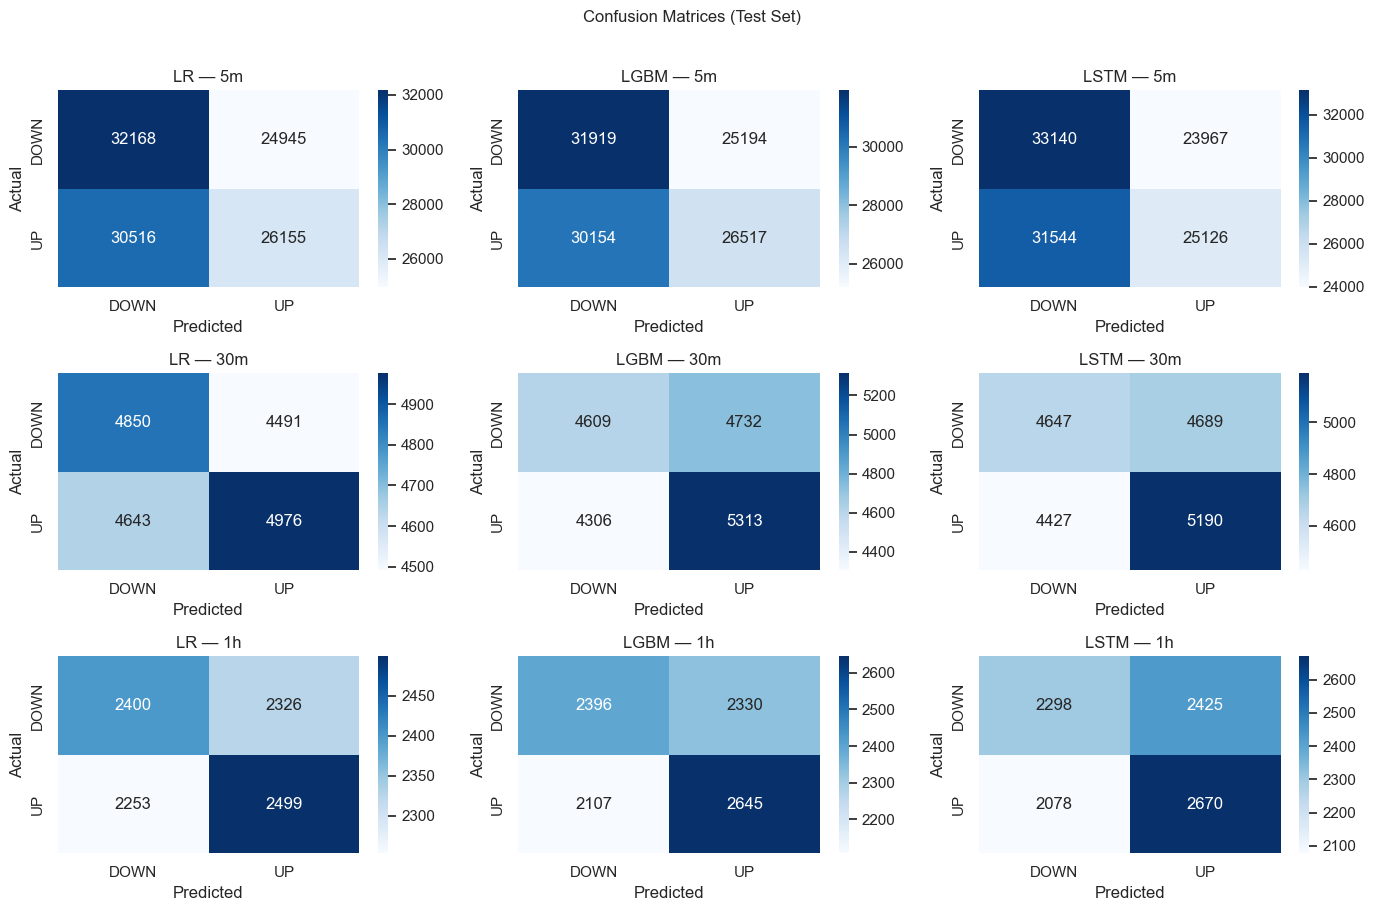

In [11]:
model_names = [n for n in ['lr', 'lgbm', 'lstm', 'tft'] if n in all_results.get(HORIZONS[0], {})]

fig, axes = plt.subplots(len(HORIZONS), len(model_names),
                          figsize=(14, 9))

for row, label in enumerate(HORIZONS):
    for col, name in enumerate(model_names):
        res = all_results[label][name]
        plot_confusion_matrix(
            res['y_true'], res['y_pred'],
            title=f'{name.upper()} — {label}',
            ax=axes[row][col],
        )

plt.suptitle('Confusion Matrices (Test Set)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 5. ROC Curves

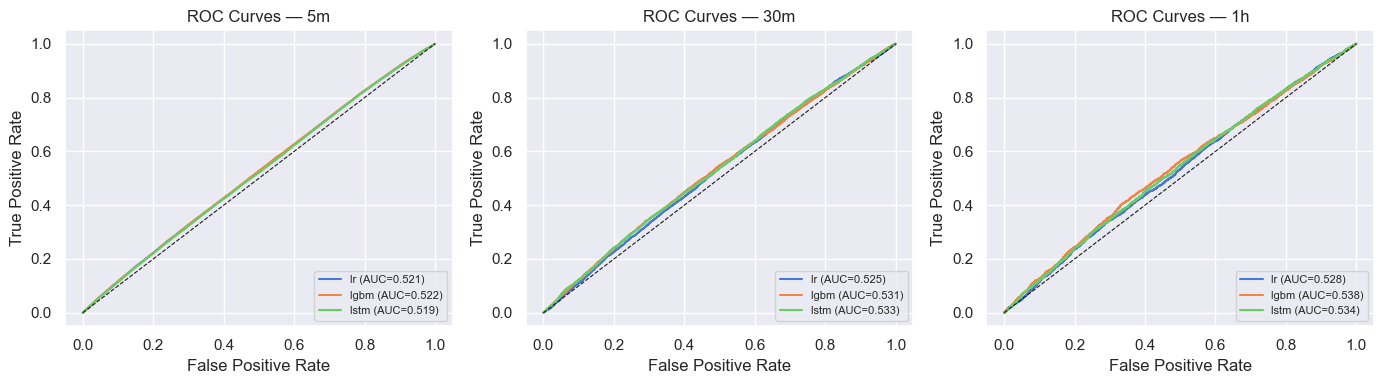

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, label in zip(axes, HORIZONS):
    plot_roc_curves(
        all_results[label],
        ax=ax,
        title=f'ROC Curves — {label}',
    )

plt.tight_layout()
plt.show()

## 6. Calibration Curves

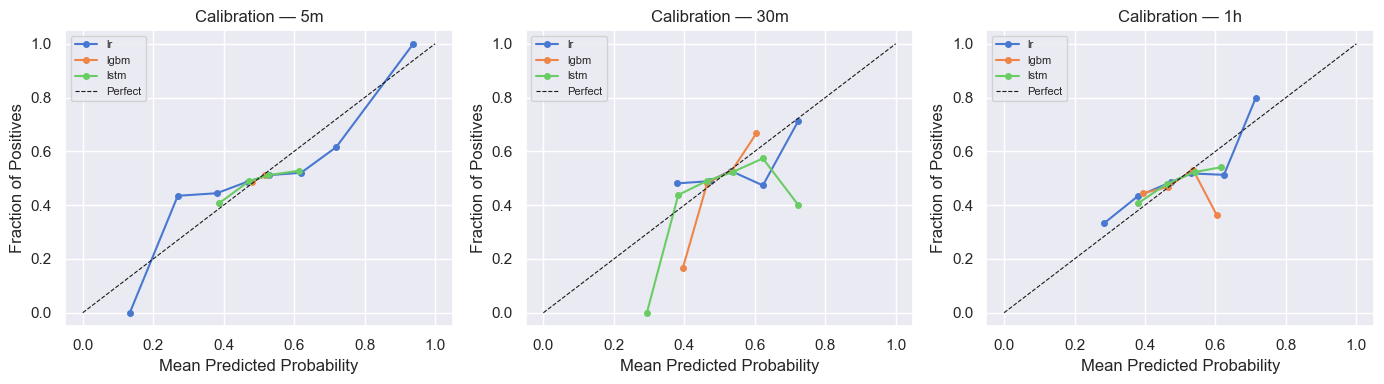

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, label in zip(axes, HORIZONS):
    plot_calibration(
        all_results[label],
        ax=ax,
        title=f'Calibration — {label}',
    )

plt.tight_layout()
plt.show()

## 7. Prediction Confidence Distribution

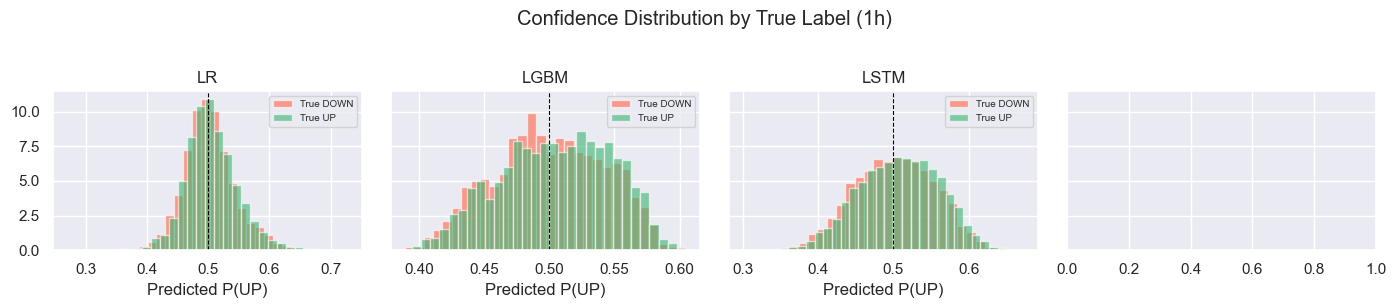

In [14]:
label = '1h'
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)

for ax, name in zip(axes, model_names):
    res = all_results[label][name]
    probs = res['y_prob']
    true  = res['y_true'].astype(int)

    ax.hist(probs[true == 0], bins=30, alpha=0.6, color='tomato',        density=True, label='True DOWN')
    ax.hist(probs[true == 1], bins=30, alpha=0.6, color='mediumseagreen', density=True, label='True UP')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(name.upper())
    ax.set_xlabel('Predicted P(UP)')
    ax.legend(fontsize=7)

plt.suptitle(f'Confidence Distribution by True Label ({label})', y=1.02)
plt.tight_layout()
plt.show()

## 8. Final Summary Table

In [16]:
results_df = aggregate_results(all_results)
print_results_table(results_df)

               accuracy  precision  recall      f1  roc_auc
horizon model                                              
5m      lr       0.5126     0.5118  0.4615  0.4854   0.5212
        lgbm     0.5136     0.5128  0.4679  0.4893   0.5223
        lstm     0.5121     0.5118  0.4434  0.4751   0.5194
30m     lr       0.5182     0.5256  0.5173  0.5214   0.5251
        lgbm     0.5233     0.5289  0.5523  0.5404   0.5315
        lstm     0.5190     0.5254  0.5397  0.5324   0.5326
1h      lr       0.5169     0.5179  0.5259  0.5219   0.5282
        lgbm     0.5319     0.5317  0.5566  0.5438   0.5377
        lstm     0.5245     0.5240  0.5623  0.5425   0.5338


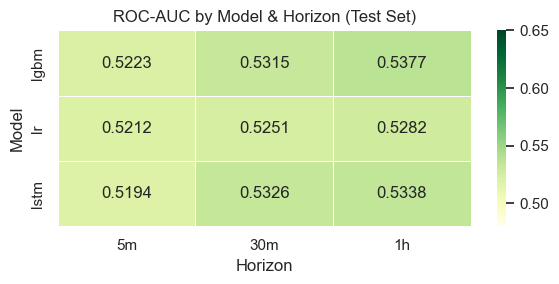

In [17]:
# Heatmap of ROC-AUC across model × horizon
auc_pivot = results_df['roc_auc'].unstack(level='horizon')[HORIZONS]

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(
    auc_pivot, annot=True, fmt='.4f', cmap='YlGn',
    vmin=0.48, vmax=0.65, linewidths=0.5, ax=ax,
)
ax.set_title('ROC-AUC by Model & Horizon (Test Set)')
ax.set_xlabel('Horizon')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

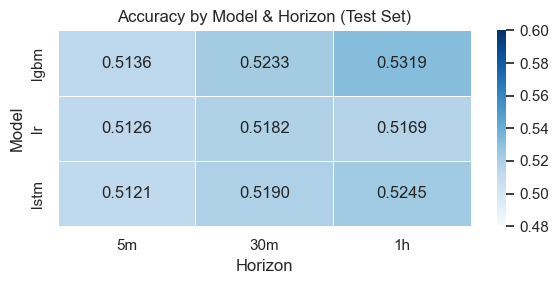

In [18]:
# Heatmap of Accuracy
acc_pivot = results_df['accuracy'].unstack(level='horizon')[HORIZONS]

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(
    acc_pivot, annot=True, fmt='.4f', cmap='Blues',
    vmin=0.48, vmax=0.60, linewidths=0.5, ax=ax,
)
ax.set_title('Accuracy by Model & Horizon (Test Set)')
ax.set_xlabel('Horizon')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

## 9. Live Inference Demo

To run live inference with the best model:
```bash
# LightGBM on 5-minute candles
python -m src.live \
    --model-path models/lgbm_5m.pkl \
    --model-type lgbm \
    --interval 5m \
    --window 48

# LSTM on 1-hour candles
python -m src.live \
    --model-path models/lstm_1h \
    --model-type lstm \
    --interval 1h \
    --window 48
```

Expected output every 60 seconds:
```
[2025-01-15 14:32:00 UTC]  BTCUSDT 1h  → UP  ▲  confidence=61.3%  candle=48.2% complete  last_price=43250.10
```